# Langgraph - 节点与可控制性
****
- 第一个Langgraph；
- 基本控制：串行控制；
- 基本控制：分支控制；
- 基本控制：条件与循环；
- 精细控制：图的运行时配置；
- 精细控制：map_reduce

第一个langgraph
****
安装环境- pip install -U langgraph

定义state(节点与节点通信的数据流)
****
TypedDict:属于Python标准库typing模块的一部分，仅提供静态类型检查，运行时不执行验证
Pydantic:第三方库、需要单独安装、提供运行时数据验证和序列化功能

In [1]:
from langchain_core.messages import AnyMessage
from pyexpat import model
from typing_extensions import TypedDict

#定义节点间通讯的消息格式
class State(TypedDict):
    messages:list[AnyMessage]
    extra_field:int

定义节点
****

In [2]:
from langchain_core.messages import AIMessage

def node(state:State):
    messages=state["messages"]
    new_message=AIMessage("你好，我是节点1")

    return {"messages":messages+[new_message],"extra_field":1}

创建图
***
包含一个节点
使用state通信

In [3]:
from langgraph.graph import StateGraph

graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()

查看节点与图结构
****
Mermaid是一种基于文本的图表和可视化工具，它允许用户通过简单的文本语法来创建复杂的图表和流程图。它特别适合开发者、文档编写库或网页中嵌入可视化内容。

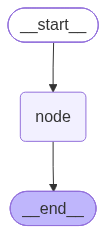

In [4]:
from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [5]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好啊，我是红狼！")]
})
result

{'messages': [HumanMessage(content='你好啊，我是红狼！', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好，我是节点1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 1}

# 使用pretty_print来格式化显示
***

In [6]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好啊，我是红狼！")]
})
for messages in result["messages"]:
    messages.pretty_print()

================================ Human Message =================================

你好啊，我是红狼！
================================== Ai Message ==================================

你好，我是节点1


串行控制
****

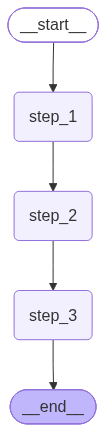

In [7]:
from typing_extensions import TypedDict
from IPython.display import Image,display
from langgraph.graph import START,StateGraph,END

class State(TypedDict):
    value_1:str
    value_2:str

def step_1(state:State):
    return {"value_1":state["value_1"]}

def step_2(state:State):
    current_value_1 = state["value_1"]
    return {"value_1":f"{current_value_1}+b"}

def step_3(state:State):
    return {"value_2":10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START,"step_1")
graph_builder.add_edge("step_1","step_2")
graph_builder.add_edge("step_2","step_3")
graph_builder.add_edge("step_3",END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"value_1": "c","value_2":9})

{'value_1': 'c+b', 'value_2': 10}

分支控制
****

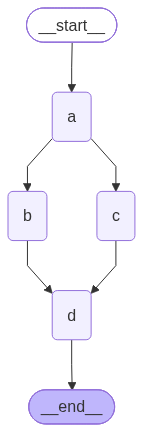

In [9]:
import operator
from typing import Any,Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Annotated允许为类型提供额外的元数据，而不影响类型检查起对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加“A”到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加“B”到{state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"添加“C”到{state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"添加“D”到{state['aggregate']}")
    return {"aggregate":["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

builder.add_edge(START,"a")
builder.add_edge("a","b")
builder.add_edge("a","c")
builder.add_edge("b","d")
builder.add_edge("c","d")
builder.add_edge("d",END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"aggregate":[]},{"configurable":{"thread":"foo"}})

添加“A”到[]
添加“B”到['A']
添加“C”到['A']
添加“D”到['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

条件分支和循环
****

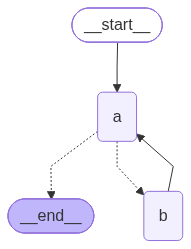

In [11]:
import operator
from typing_extensions import TypedDict
from typing import Annotated,Literal
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node A sees {state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

#Define nodes
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)

#Define edges
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","a")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"aggregate":[]})

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B']
Node B sees ['A', 'B', 'A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

使用递归限制recursion_limit来防止异常情况的大量无用调用

In [13]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke({"aggregate":[]},{"recursion_limit":4})
except GraphRecursionError:
    print("Recursion Error")

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Recursion Error


循环

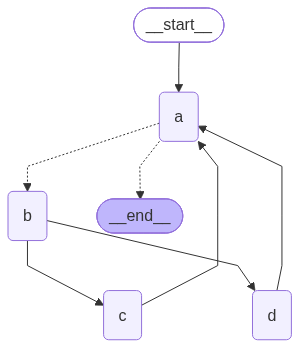

In [14]:
import operator
from typing import Any,Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Annotated允许为类型提供额外的元数据，而不影响类型检查起对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node A sees {state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"Node C sees {state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"Node D sees {state['aggregate']}")
    return {"aggregate":["D"]}

#节点
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

#边
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"])<7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","c")
builder.add_edge("b","d")
builder.add_edge(["c","d"],"a")
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
result = graph.invoke({"aggregate": []})


Node A sees []
Node B sees ['A']
Node C sees ['A', 'B']
Node D sees ['A', 'B']
Node A sees ['A', 'B', 'C', 'D']
Node B sees ['A', 'B', 'C', 'D', 'A']
Node C sees ['A', 'B', 'C', 'D', 'A', 'B']
Node D sees ['A', 'B', 'C', 'D', 'A', 'B']
Node A sees ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']


图的运行时配置
****

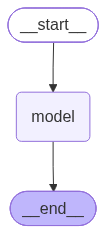

In [16]:
import operator
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END, StateGraph, START

model = ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

model1 = ChatOpenAI(
    model="ByteDance-Seed/Seed-OSS-36B-Instruct",
    temperature=0,
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_API_BASE"),
)

# 定义要切换的模型
models = {
    "deepseek": model,
    "openai": model1,
}

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

def _call_model(state:AgentState,config:RunnableConfig):
    #使用LCEL的模型
    model_name = config["configurable"].get("model", "deepseek")
    model = models[model_name]
    response = model.invoke(state["messages"])
    return {"messages":[response]}

#define a new graph
builder = StateGraph(AgentState)
builder.add_node("model",_call_model)
builder.add_edge(START, "model")
builder.add_edge("model", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

没有增加运行配置的情况下，默认使用seepseek

In [17]:
graph.invoke({"messages":[HumanMessage(content="hi,你是谁？")]})

{'messages': [HumanMessage(content='hi,你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好呀！😊我是DeepSeek Chat，一个由深度求索公司（DeepSeek）研发的智能AI助手。我可以帮你解答问题、提供建议、陪你聊天，还能处理各种文本和文件信息。有什么我可以帮你的吗？✨', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 7, 'total_tokens': 61, 'completion_tokens_details': None, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 7}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a06120aa5e75ed89db9f8de283f025', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06120-a8cd-7d90-8e0a-769501b3cb84-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 54, 'total_tokens': 61, 'input_token_details': {'cache_read': 

增加运行时配置，动态切换模型

In [18]:
config = {"configurable":{"model":"openai"}}
graph.invoke({"messages":[HumanMessage(content="hi,你是谁？")]},config=config)

{'messages': [HumanMessage(content='hi,你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi～我是豆包，是由字节跳动开发的人工智能。我能帮你回答问题、提供信息，还能陪你聊天解决各种小困惑～有什么想知道的或者需要帮忙的，都可以告诉我哦✨', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 295, 'prompt_tokens': 13, 'total_tokens': 308, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 245, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'openai', 'model_name': 'ByteDance-Seed/Seed-OSS-36B-Instruct', 'system_fingerprint': '', 'id': '01a06120b60b8a52f2dd4af5380dd3ad', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06120-b5b0-7160-ab55-ebcb7fadff5d-0', tool_calls=[], invalid_tool_

# MapRedude并执行
****
给定一个来自用户的一般主题，生成相关主题列表，为每个主题生成一个笑话，并从结果列表中选择最佳笑话
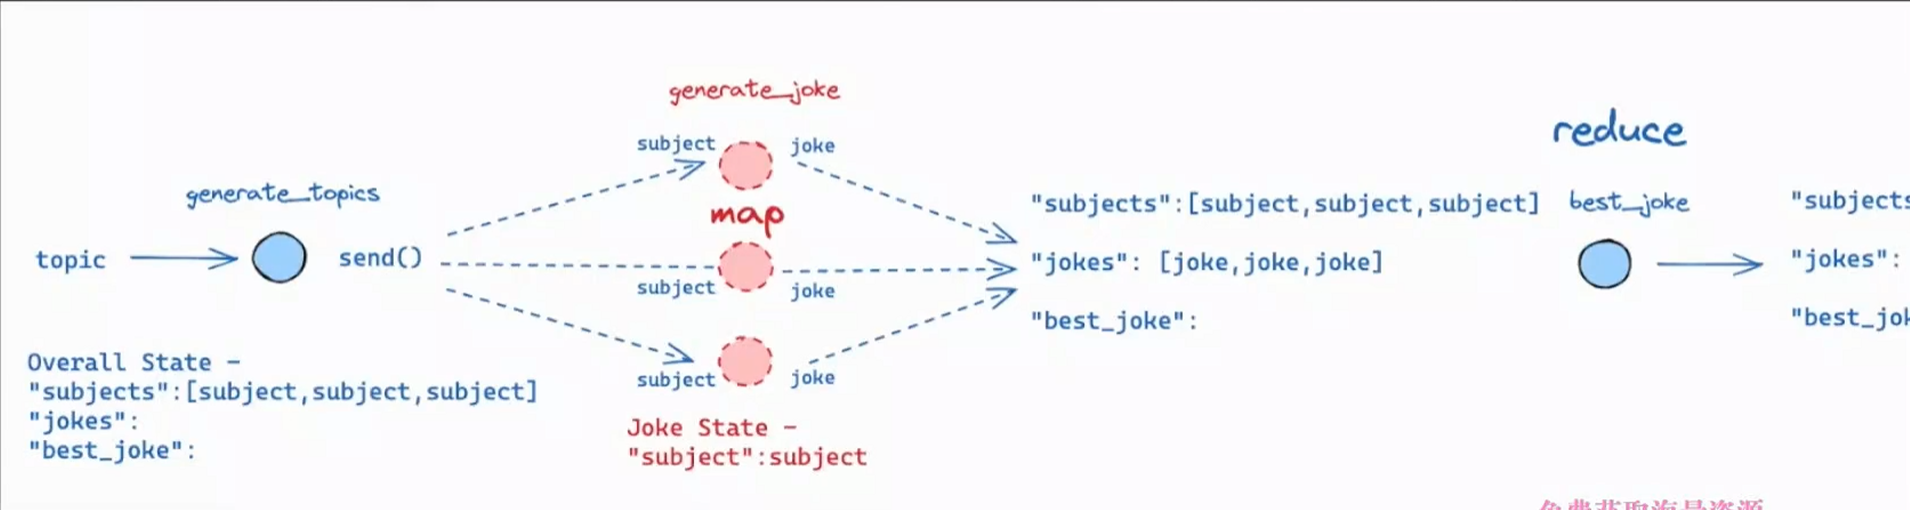

In [19]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.types import Send
from langgraph.graph import END, StateGraph, START
from pydantic import BaseModel,Field
import os

#模型和提示词
#定义我们将使用的模型和提示词
subject_prompt = """生成一个逗号分隔的列表，包含2到5个与以下主题有关的例子：{topic}。"""
joke_prompt = """生成一个关于{subject}的笑话"""
best_joke_prompt = """以下是一些关于{topic}的笑话。选出最好的一个！返回最佳笑话的ID。

{{"jokes"}}"""

class Subjects(BaseModel):
    subjects:list[str]

class Joke(BaseModel):
    joke:str

class BestJoke(BaseModel):
    id: int = Field(description="最佳的笑话索引，从0开始",ge=0)

model=ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

#这将是主图的整体状态
#它将包含一个主题（我们期望用户提供）
#然后它将生成一个主题列表，并为每一个主题生成一个笑话
class OverallState(TypedDict):
    topic:str
    subjects:list
    #注意这里我们使用oprator.add
    #这是因为我们想把从各个节点生成的所有笑话合并回一个列表-这本质上是“规约”部分
    jokes:Annotated[list,operator.add]
    best_selected_joke:str

#用于生成笑话
class JokeState(TypedDict):
    subject:str

#这是我们用来生成笑话的函数
def generate_topics(state:OverallState):
    prompt=subject_prompt.format(topic=state["topic"])
    response=model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects":response.subjects}

#这里我们根据给定的主题生成笑话
def genrate_joke(state:JokeState):
    prompt=joke_prompt.format(subject=state["subject"])
    response=model.with_structured_output(Joke).invoke(prompt)
    return {"jokes":[response.joke]}

#这里我们定义映射到生成的主题上的逻辑
#我们将在图中使用这个作为边缘
def continue_to_jokes(state:OverallState):
    #我们将返回一个'send'对象列表
    #每个'send'对象包含图中节点的名称
    #以及要发送到该节点的状态
    return [Send("generate_joke", {"subject":s}) for s in state["subjects"]]

#这里我们将评判最佳笑话
def best_joke(state:OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke":state["jokes"][response.id]}

#构建图，这里我们将所有内容组合在一起构建我们的图
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", genrate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)
app = graph.compile()

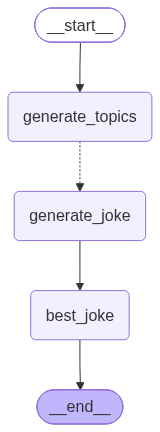

In [20]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [21]:
for s in app.stream({"topic":"曼巴"}):
    print(s)

{'generate_topics': {'subjects': ['曼巴精神', '科比·布莱恩特', 'NBA', '篮球', '曼巴蛇']}}
{'generate_joke': {'jokes': ['为什么篮球运动员总是带着梯子？因为他们总是在追求更高的目标！']}}
{'generate_joke': {'jokes': ['为什么曼巴蛇从不玩扑克？因为它总是会被人发现它在“吐”牌！']}}
{'generate_joke': {'jokes': ['为什么科比·布莱恩特总是带着篮球去睡觉？因为他想在梦里也练习曼巴精神！']}}
{'generate_joke': {'jokes': ['为什么科比·布莱恩特总是带着篮球去派对？因为他从不放过任何一个投篮的机会！']}}
{'generate_joke': {'jokes': ['为什么NBA球员不喜欢玩捉迷藏？\n\n因为他们总是被“盖帽”！']}}
{'best_joke': {'best_selected_joke': '为什么科比·布莱恩特总是带着篮球去睡觉？因为他想在梦里也练习曼巴精神！'}}


# langgraph-持久化与记忆
****
基本运用：线程隔离的持久化层
基本运用：跨线程持久化调用
记忆：短期记忆的实现
记忆：长期以及实现
记忆：使用总结技术优化记忆

线程隔离的持久化层
****

In [22]:
from langchain_deepseek import ChatDeepSeek
import os
from langgraph.graph import StateGraph,START,MessagesState

model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

def call_model(state:MessagesState):
    response = model.invoke(state["messages"])
    return {"messages":[response]}

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
graph = builder.compile()


没有激活持久化层，无法实现多轮对话

In [23]:
input_message = [{"role": "user", "content": "你好，我是红狼！"}]
for chunk in graph.stream({"messages":input_message},stream_mode="values"):
    chunk["messages"][-1].pretty_print()

input_message = [{"role": "user", "content": "我叫什么名字？"}]
for chunk in graph.stream({"messages":input_message},stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！这个名字听起来很有个性和力量感，像是从冒险故事或游戏中走出来的角色呢！😄 有什么特别的故事或寓意 behind 这个名字吗？今天想聊些什么呢？无论是游戏、动漫、户外探险，还是随便聊聊日常，我都准备好啦～
================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

目前我无法直接知道你的名字，因为我们的对话是匿名的。不过，你可以告诉我你的名字，我会记住并在接下来的对话中使用它！或者，如果你有其他问题或需要帮助，我也很乐意为你服务。😊


In [24]:
from langgraph.checkpoint.memory import MemorySaver
#使用 MemorySaver 保存中间状态
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

In [25]:
config = {"configurable":{"thread_id":"1"}}
input_message = {"role":"user","content":"你好，我是红狼！"}
for chunk in graph.stream({"messages":[input_message]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！这个名字听起来很有个性和力量感～是来自某部作品、游戏，还是你自己独特的代号呢？无论哪种，都很酷！有什么想聊的或者需要帮忙的吗？ 😄


In [26]:
input_message = {"role": "user", "content": "我叫什么名字？"}
for chunk in graph.stream({"messages":[input_message]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

哈哈，你刚刚说过啦——你叫**红狼**！这名字自带一种帅气又神秘的BGM，像荒野里的独行侠，或者某个热血故事的隐藏主角～需要我帮你记牢这个名字吗？还是说…有隐藏的“第二身份”要解锁？ 😎


注意thread_id的输入

In [27]:
input_messages = {"role": "user", "content": "我叫什么名字"}
for chunk in graph.stream(
    {"messages":[input_messages]},
    {"configurable":{"thread_id":"2"}},#diffrent thread_id
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字
================================== Ai Message ==================================

你还没有告诉我你的名字呢！😊 你可以告诉我你的名字，我会记住并用来称呼你～或者，如果你希望我帮你起个有趣的名字，我也可以给你推荐几个！比如：星辰、小智、阳光、乐乐……你喜欢哪一个？或者有其他想法吗？


# 跨线程共享持久化数据
****
使用userid

设置内存记忆

In [28]:
from langgraph.store.memory import InMemoryStore
from langchain_openai import OpenAIEmbeddings
import os
#使用OPENAI的封装，但是运行国产化模型
#使用内存存储来保存向量化后记忆数据
in_memory_store = InMemoryStore(
    index={
        "embed":OpenAIEmbeddings(
            model="Pro/BAAI/bge-m3",
            api_key=os.environ.get("OPENAI_API_KEY"),
            base_url=os.environ.get("OPENAI_API_BASE")
        ),
        "dims":1024,
    }
)

In [29]:
import uuid #使用UUID来生成唯一的线程ID
from typing import Annotated
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
import os
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph,MessagesState,START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

#注意：我们将Store参数传递给节点
#这是我们编译图时使用的Store
def call_model(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    #从存储中检索用户信息
    user_id = config["configurable"].get("user_id")
    #从存储中检索用户信息
    namespace = ("memories",user_id)
    memories = store.search(namespace,query=str(state["messages"][-1].content))
    info = "\n".join([d.value["data"] for d in memories])
    system_msg = f"你是一个正在与用户交谈的小助手。用户信息{info}"
    print(f"在内存中检索用户信息：{info}")

    #如果用户要求模型记住信息，则存储新的记忆
    last_message = state["messages"][-1]
    if "记住" in last_message.content.lower() or "remenber" in last_message.content.lower():
        #硬编码一个记忆
        memory = "用户名字是红狼"
        store.put(namespace,str(uuid.uuid4()),{"data":memory})

    response = model.invoke(
        [{"role":"system","content":system_msg}] + state["messages"]
    )
    return {"messages":response}

builder = StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")

#注意，我们在编译图时传递了store对象
graph = builder.compile(checkpointer=MemorySaver(),store=in_memory_store)

注意线程ID和用户ID

In [30]:
config={"configurable":{"thread_id":1,"user_id":"1"}}
input_message = {"role":"user","content":"请记住我的名字叫红狼!"}
for chunk in graph.stream({"messages":input_message},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

请记住我的名字叫红狼!
在内存中检索用户信息：
================================== Ai Message ==================================

好的，红狼！我会记住你的名字。有什么我可以帮你的吗？😊


跨线程使用相同的用户ID查询

In [31]:
#注意线程ID和用户ID
config={"configurable":{"thread_id":2,"user_id":"1"}}
input_message = {"role":"user","content":"我叫什么名字!"}
for chunk in graph.stream({"messages":input_message},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字!
在内存中检索用户信息：用户名字是红狼
================================== Ai Message ==================================

你的名字是红狼！有什么我可以帮你的吗？


我们可以查询存储在内存中的记忆

In [32]:
for memory in in_memory_store.search(("memories","1")):
    print(memory.value)

{'data': '用户名字是红狼'}


用户级的记忆隔离

In [33]:
config={"configurable":{"thread_id":3,"user_id":"2"}}
input_message = {"role":"user","content":"我叫什么名字!"}
for chunk in graph.stream({"messages":input_message},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什么名字!
在内存中检索用户信息：
================================== Ai Message ==================================

哈哈，看来你考到我了！目前我还不知道你的名字，不过你可以告诉我呀～ 😄 或者你想让我给你起个有趣的名字？比如“小太阳”或者“冒险家”之类的？


**短期记忆的实现**
****
*基于最简单的ReAct智能体

In [34]:
from typing import Literal

from langchain_deepseek import ChatDeepSeek
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,StateGraph,START,END
from langgraph.prebuilt import ToolNode

#使用内存存储来读取记忆
memory=MemorySaver()

@tool
def search(query:str):
    """调用此函数可以浏览网络"""
    #模拟一个网络搜索并返回
    return "北京天气晴朗 大约22度 湿度30%"

tools=[search]
tool_node = ToolNode(tools)
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)
bound_model = model.bind_tools(tools)

def should_continue(state:MessagesState):
    """返回下一个要执行的节点"""
    last_messages = state["messages"][-1]
    #如果没有函数调用，则结束
    if not last_messages.tool_calls:
        return END
    #否则如果有，我们继续
    return "action"

#定义调用模型的函数
def call_model(state:MessagesState):
    response = bound_model.invoke(state["messages"])
    #我们返回一个列表，因为这会被添加到现有列表中
    return {"messages":response}

#定义一个圈
workflow = StateGraph(MessagesState)

#定义我们将在其间循环的两个节点
workflow.add_node("agent",call_model)
workflow.add_node("action",tool_node)

#将入口点设置为‘agent’
#这意味着这个节点是第一个被调用的
workflow.add_edge(START,"agent")

#现在我们添加一个条件边
workflow.add_conditional_edges(
    #首先，我们定义起始节点，我们使用‘agent’
    #这意味着这些是在‘agent’节点被调用后采取的边。
    "agent",
    #接下来，我们传入将确定下一个调用哪个节点的函数
    should_continue,
    #接下来，我们传入路径映射 - 这条边可能去往的所有节点
    ["action",END],
)

#现在我们从‘tools’到‘agent’添加一个普通边。
#这意味着在调用‘tools’之后，接下来调用‘agent’节点。
workflow.add_edge("action","agent")

#最后，我们编译它！
#这将它编译成一个 LangChain Runnable
# 这意味着你可以像使用任何其他 runnable 一样使用它
# 设置检查点为内存形式，注意有没有设置store
app = workflow.compile(checkpointer=memory)

调用图

In [36]:
from langchain_core.messages import HumanMessage

config={"configurable":{"thread_id":20}}
input_message = HumanMessage(content="你好，我是红狼！")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

input_message = HumanMessage(content="我叫什么名字？")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！很高兴认识你！有什么我可以帮你的吗？
================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

你刚刚告诉我你的名字是“红狼”！需要我帮你记住这个名字吗？或者有其他事情需要我帮忙？


# 长期记忆
****
- 使用MongDB

- 在本地安装MongoDB
- windows（已选择）：

In [37]:
#安装后，启动MongoDB服务
#通常安装后会自动设置为系统服务并启动
#如果没有自动启动，可以在命令行提示符中运行：
#net start MongoDB

- macos

In [38]:
#安装
# brew tap mongodb/brew
# brew install mongodb-community

#启动服务
# brew services start mongodb-community

- 使用docker快速安装

In [39]:
# 拉取MongDB镜像
# docker pull docker.1ms.ioo/mongo

#运行MongDB容器
# docker run -d -p 27017:27017 --name mongdb mongo

#验证容器是否运行
# docker ps

连接mongodb

In [40]:
! pip install -U pymongo langgraph langgraph-checkpoint-mongodb

     -------------------------------------- 815.7/815.7 kB 1.5 MB/s eta 0:00:00
     ------------------------------------- 331.1/331.1 kB 10.4 MB/s eta 0:00:00
     -------------------------------------- 804.8/804.8 kB 6.4 MB/s eta 0:00:00
     ---------------------------------------- 62.0/62.0 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 113.2/113.2 kB 6.9 MB/s eta 0:00:00
     -------------------------------------- 148.0/148.0 kB 8.6 MB/s eta 0:00:00
     ---------------------------------------- 1.0/1.0 MB 9.5 MB/s eta 0:00:00
     ---------------------------------------- 2.2/2.2 MB 5.7 MB/s eta 0:00:00
     ------------------------------------- 322.8/322.8 kB 10.1 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


测试MongoDB连接

In [44]:
import pymongo

#创建MongoDB客户端连接
cilent = pymongo.MongoClient("mongodb://localhost:27017/")

#测试连接
try:
    cilent.admin.command('ping')
    print("MongoDB连接成功！")
except Exception as e:
    print(f"MongoDB连接失败:{e}")

MongoDB连接成功！


创建一个最简单的智能体

In [47]:
from typing import Literal

from langchain_core.tools import tool
from langchain_deepseek import ChatDeepSeek
from langgraph.prebuilt import create_react_agent

@tool
def get_weather(city:Literal["北京","深圳"]):
    """用来返回天气信息的工具函数"""
    if city == "北京":
        return "北京天气晴朗 大约22度 湿度30%"
    elif city == "深圳":
        return "深圳天气多云 大约28度 湿度80%"
    else:
        raise AssertionError("Unknown city")

tools = [get_weather]
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

连接mongodb进行查询

In [48]:
from langgraph.checkpoint.mongodb import MongoDBSaver

MONGODB_URI = "localhost:27017" #replace this with your connection string

with MongoDBSaver.from_conn_string(MONGODB_URI) as checkpointer:
    graph = create_react_agent(model,tools=tools,checkpointer=checkpointer)
    config = {"configurable":{"thread_id":"1"}}
    response = graph.invoke(
        {"messages":[("human","北京今天的天气如何？")]},config
    )


C:\Users\31354\AppData\Local\Temp\ipykernel_4616\3326755007.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(model,tools=tools,checkpointer=checkpointer)


In [50]:
print(response)

{'messages': [HumanMessage(content='北京今天的天气如何？', additional_kwargs={}, response_metadata={}, id='b2f27350-def2-4b9f-ad72-d9ae6bd21db1'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 100, 'total_tokens': 119, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 100}, 'model_provider': 'deepseek', 'model_name': 'Pro/deepseek-ai/DeepSeek-V3', 'system_fingerprint': '', 'id': '01a06134d4663a6b0082b8683a6d5626', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06134-d35f-7773-9316-f2ec0034d728-0', tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'},

### 优化记忆
****
- 消息过滤：对旧消息进行类似删除或编辑的操作，目的是为了防止撑爆上下文
- 消息总结：对旧消息进行总结，目的一样是为了防止记忆内容过长
- 注意对记忆的管理是一项关于召回率和精度的平衡艺术

In [61]:
from typing import Literal

from langchain_deepseek import ChatDeepSeek
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,StateGraph,START
from langgraph.prebuilt import ToolNode

memory = MemorySaver()

@tool
def search(query:str):
    """调用此函数可以浏览网络"""
    #模拟一个网络搜索并返回
    return "北京天气晴朗 大约22度 湿度30%"

tools=[search]
tool_node = ToolNode(tools)
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)
bound_model = model.bind_tools(tools)

def should_continue(state:MessagesState):
    """返回下一个要执行的节点"""
    last_messages = state["messages"][-1]
    #如果没有函数调用，则结束
    if not last_messages.tool_calls:
        return END
    #否则如果有，我们继续
    return "action"

def filter_messages(messages:list):
    #这是一个非常简单的辅助函数，它只使用最后一条消息
    return messages[-1:]

#定义调用模型的函数
def call_model(state:MessagesState):
    messages = filter_messages(state["messages"])
    response = bound_model.invoke(messages)
    #我们返回一个列表，因为这会被添加到现有列表中
    return {"messages":response}

#定义一个圈
workflow = StateGraph(MessagesState)

#定义我们将在其间循环的两个节点
workflow.add_node("agent",call_model)
workflow.add_node("action",tool_node)

#将入口点设置为‘agent’
#这意味着这个节点是第一个被调用的
workflow.add_edge(START,"agent")

#现在添加一个条件边
workflow.add_conditional_edges(
    #首先，我们定义起始节点，我们使用‘agent’
    #这意味着这些是在‘agent’节点被调用后采取的边。
    "agent",
    #接下来，我们传入将确定下一个调用哪个节点的函数
    should_continue,
    #接下来，我们传入路径映射 - 这条边可能去往的所有节点
    ["action",END],
)

#现在我们从‘action’到‘agent’添加一个普通边。
#这意味着在调用‘action’之后，接下来调用‘agent’节点。
workflow.add_edge("action","agent")

#最后，我们编译它！
#这将它编译成一个 LangChain Runnable
# 这意味着你可以像使用任何其他 runnable 一样使用它
# 设置检查点为内存形式，注意有没有设置store
app = workflow.compile(checkpointer=memory)

进行调用，由于进行了消息裁剪，所以即便使用了memory，依然无法记住过往对话

In [62]:
from langchain_core.messages import HumanMessage

config={"configurable":{"thread_id":2}}
input_message = HumanMessage(content="你好，我是红狼！")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

#注意，我们在这里使用了一个辅助函数，它只使用最后一条消息
#这将导致我们的模型只看到最后一条消息
input_message = HumanMessage(content="我叫什么名字？")
for event in app.stream({"messages":input_message},config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！很高兴认识你！有什么我可以帮你的吗？
================================ Human Message =================================

我叫什么名字？
================================== Ai Message ==================================

我不知道你的名字。你可以告诉我你的名字，我会记住它！


使用对话总结技术在实战中更为常见

In [71]:
from typing import Literal

from langchain_deepseek import ChatDeepSeek
from langchain_core.messages import SystemMessage,RemoveMessage,HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,StateGraph,START,END

memory = MemorySaver()

#我们将添加一个‘summary’属性（除了MessagesState已有的‘messages’键之外）
class State(MessagesState):
    summary:str

#我们将使用这个模型进行对话和总结
model = ChatDeepSeek(
    model = "Pro/deepseek-ai/DeepSeek-V3",
    temperature=0, 
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

#定义调用模型的逻辑
def call_model(state:MessagesState):
    #如果存在摘要，我们将其作为系统消息添加
    summary = state.get("summary","")
    if summary:
        system_message = f"之前对话的摘要：{summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    response = model.invoke(messages)
    #我们返回一个列表，因为这将被添加到现有列表中
    return {"messages":[response]}

#现在我们定义确定是结束还是总结对话的逻辑
def should_continue(state:State) -> Literal["summarize_conversation",END]:
    """返回下一个要执行的节点"""
    messages = state["messages"]
    #如果消息超过六条，则我们总结对话
    if len(messages)>6:
        return "summarize_conversation"
    #否则我们可以直接结束
    return END

def summarize_conversation(state:State):
    #首先，我们总结对话
    summary = state.get("summary","")
    if  summary:
        #如果已经存在摘要，我们要使用不用的系统提示来总结它
        #与没有摘要的情况不同
        summary_message = (
            f"这是迄今为止对话的摘要：{summary}\n\n"
            "考虑上面的新消息，扩展需要"
        )
    else:
        summary_message = "创建上述对话的摘要："

    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    #现在我们需要删除我们不再想显示的消息
    #我将删除除最后两条以外的所有消息，但你可以更改这一点
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content,"messages":delete_messages}

#定义一个新图
workflow = StateGraph(State)

#定义对话节点和总结节点
workflow.add_node("conversation",call_model)
workflow.add_node(summarize_conversation)

#将入口点设置为对话
workflow.add_edge(START,"conversation")

#现在添加一个条件边
workflow.add_conditional_edges(
    #首先，我们定义起始节点。我们使用‘conversation'
    #这意味着这些是在调用’conversation‘节点后采取的边
    "conversation",
    #接下来，我们传入将确定下一个调用哪个节点的函数
    should_continue,
)

#现在我们从‘summarize_conversation’到END添加一个普通边。
#这意味着在调用‘summarize_conversation‘之后，我们结束。
workflow.add_edge("summarize_conversation",END)

#最后，我们编译它
app = workflow.compile(checkpointer=memory)


升级一下print函数以便可以更清晰的看到记忆过程

In [72]:
def print_update(update):
    for k,v in update.items():
        for m in v["messages"]:
            m.pretty_print()
        if "summary" in v:
            print(v["summary"])

In [73]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id":"4"}}
input_message = HumanMessage(content="你好，我是红狼！")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

input_message = HumanMessage(content="我叫什么名字?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)
    
input_message = HumanMessage(content="我喜欢玩三角洲！")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

你好，我是红狼！
================================== Ai Message ==================================

你好，红狼！这个名字听起来很有个性和力量感，像是从冒险故事或游戏中走出来的角色呢！😄 有什么特别的故事或原因让你选择这个名字吗？或者今天有什么想聊的话题？无论是游戏、动漫、科幻，还是日常趣事，我都乐意陪你聊聊～ 

（如果真的是某部作品的角色粉，也可以悄悄告诉我，避免剧透哦！）
================================ Human Message =================================

我叫什么名字?
================================== Ai Message ==================================

哈哈，你刚刚告诉我你叫 **“红狼”** 呀！这名字我可不会忘～（除非你偷偷用了“隐身斗篷”之类的道具？😉）  

需要我帮你记住其他信息吗？比如喜欢的颜色、游戏角色，或者下次打招呼的暗号？ *（比如：“嗷呜~” 之类的？）*
================================ Human Message =================================

我喜欢玩三角洲！
================================== Ai Message ==================================

哈哈，**三角洲（Delta Force）**！经典啊！🎮 你指的是老派的《三角洲特种部队》系列，还是最近新出的游戏？  

- 如果是**复古党**，我猜你肯定怀念那种硬核战术配合和开阔地图的爽快感！  
- 如果是**新玩家**，说不定我们在聊《三角洲行动》（*Delta Force: Hawk Ops*）？最近测试挺火的！  

**悄悄问：** 你最喜欢哪种玩法？  
👉 比如“潜行摸哨”、“突突突火力压制”，还是“当老六蹲人”？ （*队友：这